# 06 Final Backtest and Business Impact

Load the primary Step 3 model, create untouched test predictions, apply a long-or-cash policy, subtract 10 basis points whenever a position changes, compare with an equal-weight benchmark, and save reproducible report artifacts.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtesting import monthly_returns, performance_metrics, run_long_cash_backtest

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load the fitted pipeline and make test predictions

In [2]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_sizes=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        previous = input_size
        for hidden in hidden_sizes:
            layers.extend([nn.Linear(previous, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout)])
            previous = hidden
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs)


test = pd.read_csv(PROCESSED_DIR / "test.csv", parse_dates=["Date"])
feature_cols = joblib.load(MODELS_DIR / "feature_cols.joblib")
checkpoint = torch.load(MODELS_DIR / "feedforward_nn_step3.pt", map_location=DEVICE)
model = FeedForwardNN(
    checkpoint["input_size"],
    tuple(checkpoint["hidden_sizes"]),
    checkpoint["dropout"],
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with torch.no_grad():
    predictions = model(torch.tensor(test[feature_cols].to_numpy(np.float32), device=DEVICE)).squeeze(1).cpu().numpy()

prediction_rows = test[["Date", "Ticker", "target_next_day_logreturn"]].rename(
    columns={"target_next_day_logreturn": "actual_return"}
)
prediction_rows["prediction"] = predictions
prediction_rows.head()

,Date,Ticker,actual_return,prediction
0,2022-12-08,AAPL,-0.003441,0.001591
1,2022-12-09,AAPL,0.016257,0.001547
2,2022-12-12,AAPL,0.006759,0.001511
3,2022-12-13,AAPL,-0.015658,0.001600
4,2022-12-14,AAPL,-0.047987,0.001596


## Run the strategy net of transaction costs

In [3]:
asset_results, daily = run_long_cash_backtest(
    prediction_rows,
    transaction_cost_bps=10.0,
)
strategy_metrics = performance_metrics(daily)

benchmark_daily = (
    prediction_rows.groupby("Date", as_index=False)["actual_return"]
    .mean()
    .sort_values("Date")
    .rename(columns={"actual_return": "net_return"})
)
benchmark_metrics = performance_metrics(benchmark_daily)

comparison = pd.DataFrame(
    [
        {"Portfolio": "Feedforward long/cash", **strategy_metrics},
        {"Portfolio": "Equal-weight buy/hold", **benchmark_metrics},
    ]
).set_index("Portfolio")
comparison

,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,final_value,dollar_pnl,trading_days
Portfolio,,,,,,,,
Feedforward long/cash,0.540296,0.153566,0.121973,1.171226,-0.168956,1.540296e+06,540295.639256,762
Equal-weight buy/hold,0.646661,0.179323,0.134253,1.228583,-0.172971,1.646661e+06,646660.987022,762


## Plot equity and drawdown

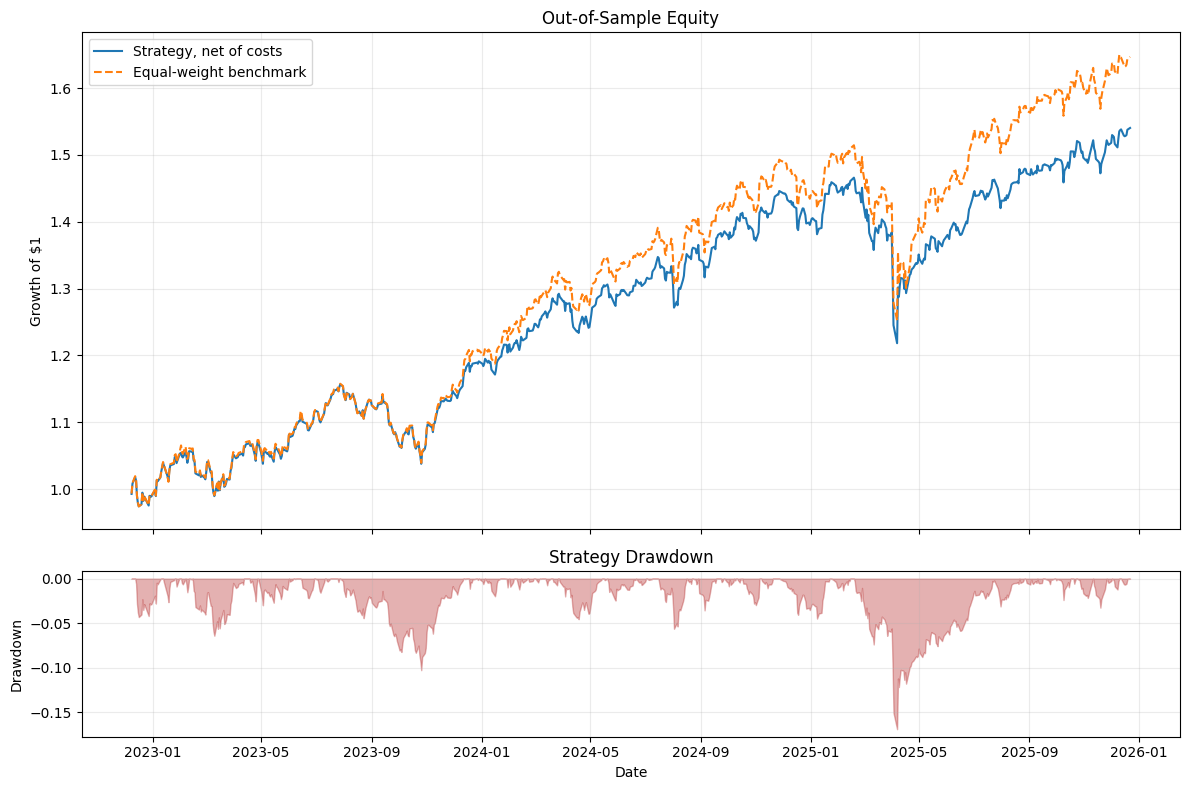

In [4]:
benchmark_daily["equity"] = np.exp(benchmark_daily["net_return"].cumsum())

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(daily["Date"], daily["equity"], label="Strategy, net of costs")
axes[0].plot(benchmark_daily["Date"], benchmark_daily["equity"], label="Equal-weight benchmark", linestyle="--")
axes[0].set(title="Out-of-Sample Equity", ylabel="Growth of $1")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].fill_between(daily["Date"], daily["drawdown"], 0, color="firebrick", alpha=0.35)
axes[1].set(title="Strategy Drawdown", ylabel="Drawdown", xlabel="Date")
axes[1].grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## Save report artifacts

In [5]:
monthly = monthly_returns(daily)
asset_results.to_csv(OUTPUT_DIR / "test_predictions_and_positions.csv", index=False)
daily.to_csv(OUTPUT_DIR / "daily_portfolio.csv", index=False)
monthly.to_csv(OUTPUT_DIR / "monthly_returns.csv")
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv")

recommendation = "ITERATE" if strategy_metrics["sharpe_ratio"] > 0 else "ABANDON"
summary = f'''# Stock Market Deep Learning Executive Summary

## Recommendation

**{recommendation}.** This is a research backtest, not a production trading approval.

## Test Result

- Final value of $1,000,000: ${strategy_metrics["final_value"]:,.0f}
- Net dollar P&L: ${strategy_metrics["dollar_pnl"]:,.0f}
- Net annualized return: {strategy_metrics["annualized_return"]:.2%}
- Net Sharpe ratio: {strategy_metrics["sharpe_ratio"]:.2f}
- Maximum drawdown: {strategy_metrics["max_drawdown"]:.2%}
- Transaction cost: 10 basis points per position change

## Benchmark

The equal-weight buy-and-hold benchmark returned {benchmark_metrics["annualized_return"]:.2%} annualized with a Sharpe ratio of {benchmark_metrics["sharpe_ratio"]:.2f}.

## Limitations

The dataset may contain survivorship bias. The simulation omits market impact, taxes, borrow constraints, latency, and live-data failures. Market regimes can change, so historical performance does not guarantee future results.
'''
(OUTPUT_DIR / "executive_summary.md").write_text(summary, encoding="utf-8")
print(f"Saved generated artifacts to {OUTPUT_DIR}")

Saved generated artifacts to C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ml_2\reports\generated
